In [1]:
import rasterio
import pandas as pd
import numpy as np

# Buka file GeoTIFF
tif_file = r"D:\ITB\TA\Data\09. Temperature\mars_yearly_maximum_temperature_v1.0.tif"

with rasterio.open(tif_file) as src:
    
    # Ambil data raster band pertama
    band = src.read(1)
    
    # Ambil ukuran raster
    rows, cols = band.shape
    
    data = []

    # Loop semua pixel
    for row in range(rows):
        for col in range(cols):
            
            # Nilai pixel
            value = band[row, col]
            
            # Skip nilai kosong (NoData)
            if value == src.nodata:
                continue
            
            # Konversi pixel ke koordinat
            lon, lat = src.xy(row, col)
            
            data.append({
                "Longitude": lon,
                "Latitude": lat,
                "Suhu": value
            })

# Ubah ke dataframe
df = pd.DataFrame(data)

# Simpan CSV
df.to_csv("temp_yearly_max.csv", index=False)

print("Selesai!")
print(df.head())

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Selesai!
   Longitude  Latitude        Suhu
0        0.5       0.5  245.369995
1        1.5       0.5  245.369995
2        2.5       0.5  245.369995
3        3.5       0.5  245.369995
4        4.5       0.5  245.369995


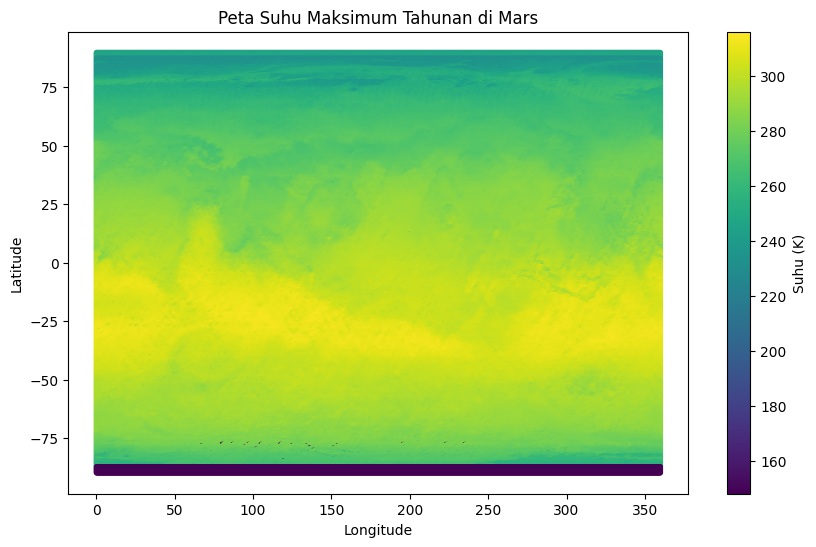

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data dari CSV
df_bersih = pd.read_csv(r"D:\ITB\TA\Ngolah Data\09. Temperature\temp_yearly_max.csv")

df_bersih["Longitude"] = df_bersih["Longitude"] * 360 / 720
df_bersih["Latitude"] =90 - (df_bersih["Latitude"] * 180 / 360)


# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_bersih["Longitude"], df_bersih["Latitude"], c=df_bersih["Suhu"], cmap="viridis", s=10)
plt.colorbar(label="Suhu (K)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Suhu Maksimum Tahunan di Mars")


plt.show()

In [2]:
df_after0 = df_bersih[(df_bersih["Suhu"] > 0)]
print(df_after0.head())

   Longitude  Latitude    Suhu
0       0.25     89.75  245.37
1       0.75     89.75  245.37
2       1.25     89.75  245.37
3       1.75     89.75  245.37
4       2.25     89.75  245.37


In [4]:
counts_after0 = df_after0["Suhu"].value_counts().sort_index()

print(counts_after0)

Suhu
148.000    4343
231.229       3
231.230       1
231.774       1
231.775       1
           ... 
315.454       1
315.705       1
315.790       1
315.809       1
316.132       1
Name: count, Length: 65995, dtype: int64


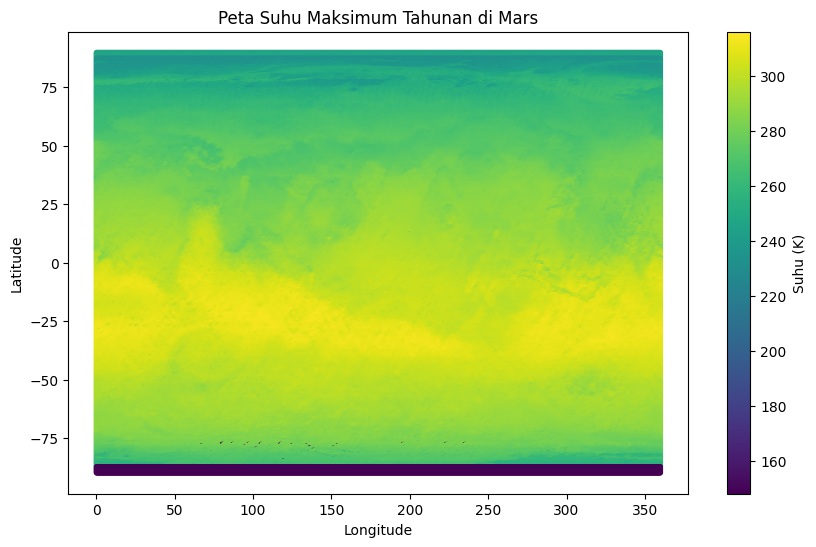

In [5]:
# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_after0["Longitude"], df_after0["Latitude"], c=df_after0["Suhu"], cmap="viridis", s=10)
plt.colorbar(label="Suhu (K)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Suhu Maksimum Tahunan di Mars")


plt.show()

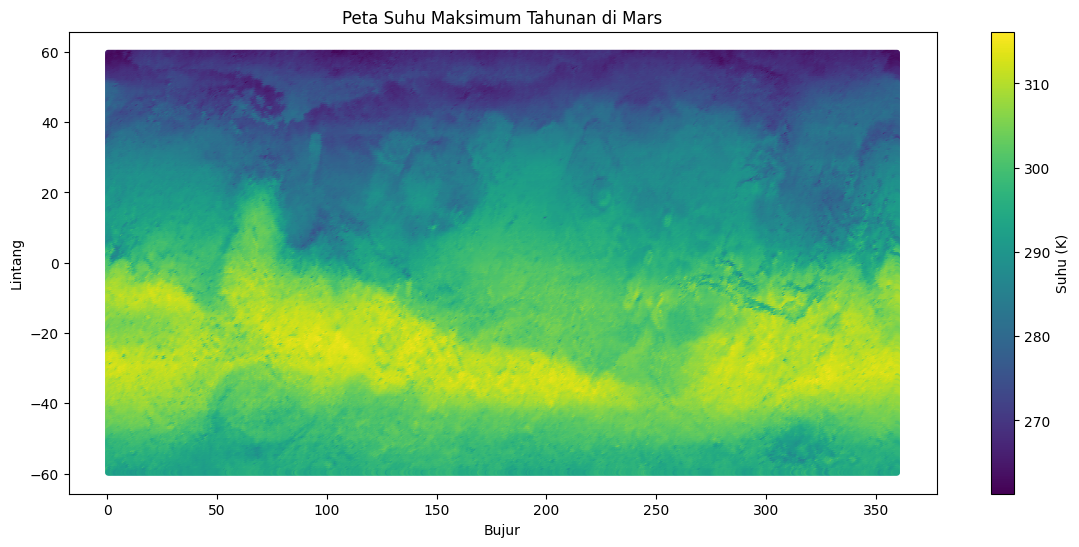

In [3]:
df_nonkutub = df_after0[(df_after0["Latitude"] < 60) & (df_after0["Latitude"] > -60)]
plt.figure(figsize=(14, 6))
plt.scatter(df_nonkutub["Longitude"], df_nonkutub["Latitude"], c=df_nonkutub["Suhu"], cmap="viridis", s=10)
plt.colorbar(label="Suhu (K)")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Suhu Maksimum Tahunan di Mars")
# balik sumbu y
plt.show()